# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

df = pd.read_csv("data/processed/cleaned_2003_present.csv")
# Convert to datetime
df['Incident Date'] = pd.to_datetime(df['Incident Date'])

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_35312/3427515592.py:13: DtypeWarning: Columns (11,13,16,17,18,19,20,21,22,24,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/cleaned_2003_present.csv")


Year with the most incidents: 2018
Year with the least incidents: 2025


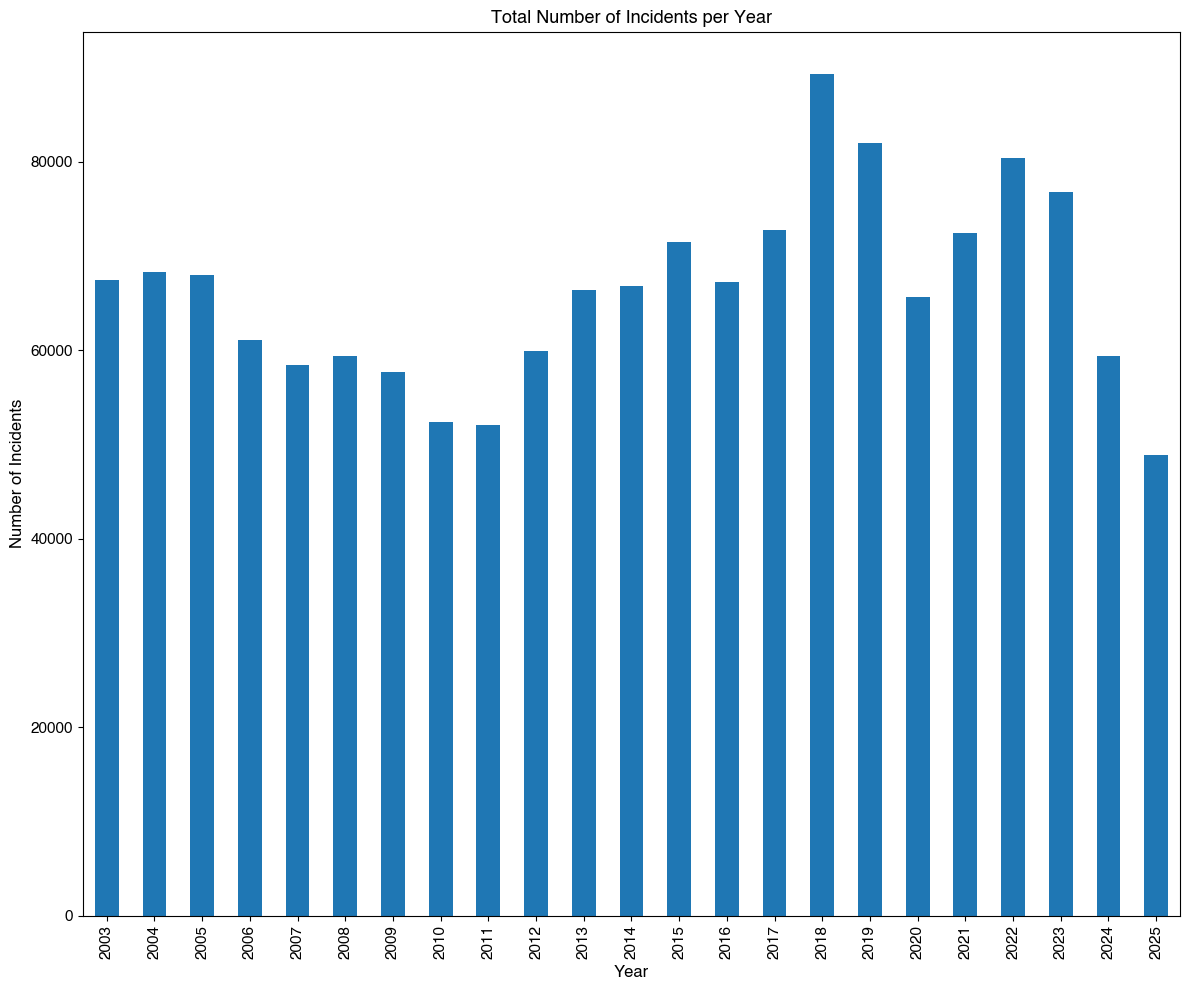

In [60]:
# Create a bar chart showing incidents by year


# Count the total number of incidents per year
incidents_per_year = df['Incident Year'].value_counts().sort_index()

# Which year had the most incidents? 
print('Year with the most incidents:',incidents_per_year.idxmax())

# Which year had the least incidients?
print('Year with the least incidents:',incidents_per_year.idxmin())

# Create a bar chart showing the incidents by year
incidents_per_year.plot(kind='bar', figsize=(12,10))
plt.ylabel('Number of Incidents')
plt.xlabel('Year')
plt.title('Total Number of Incidents per Year')

plt.tight_layout()
plt.show()


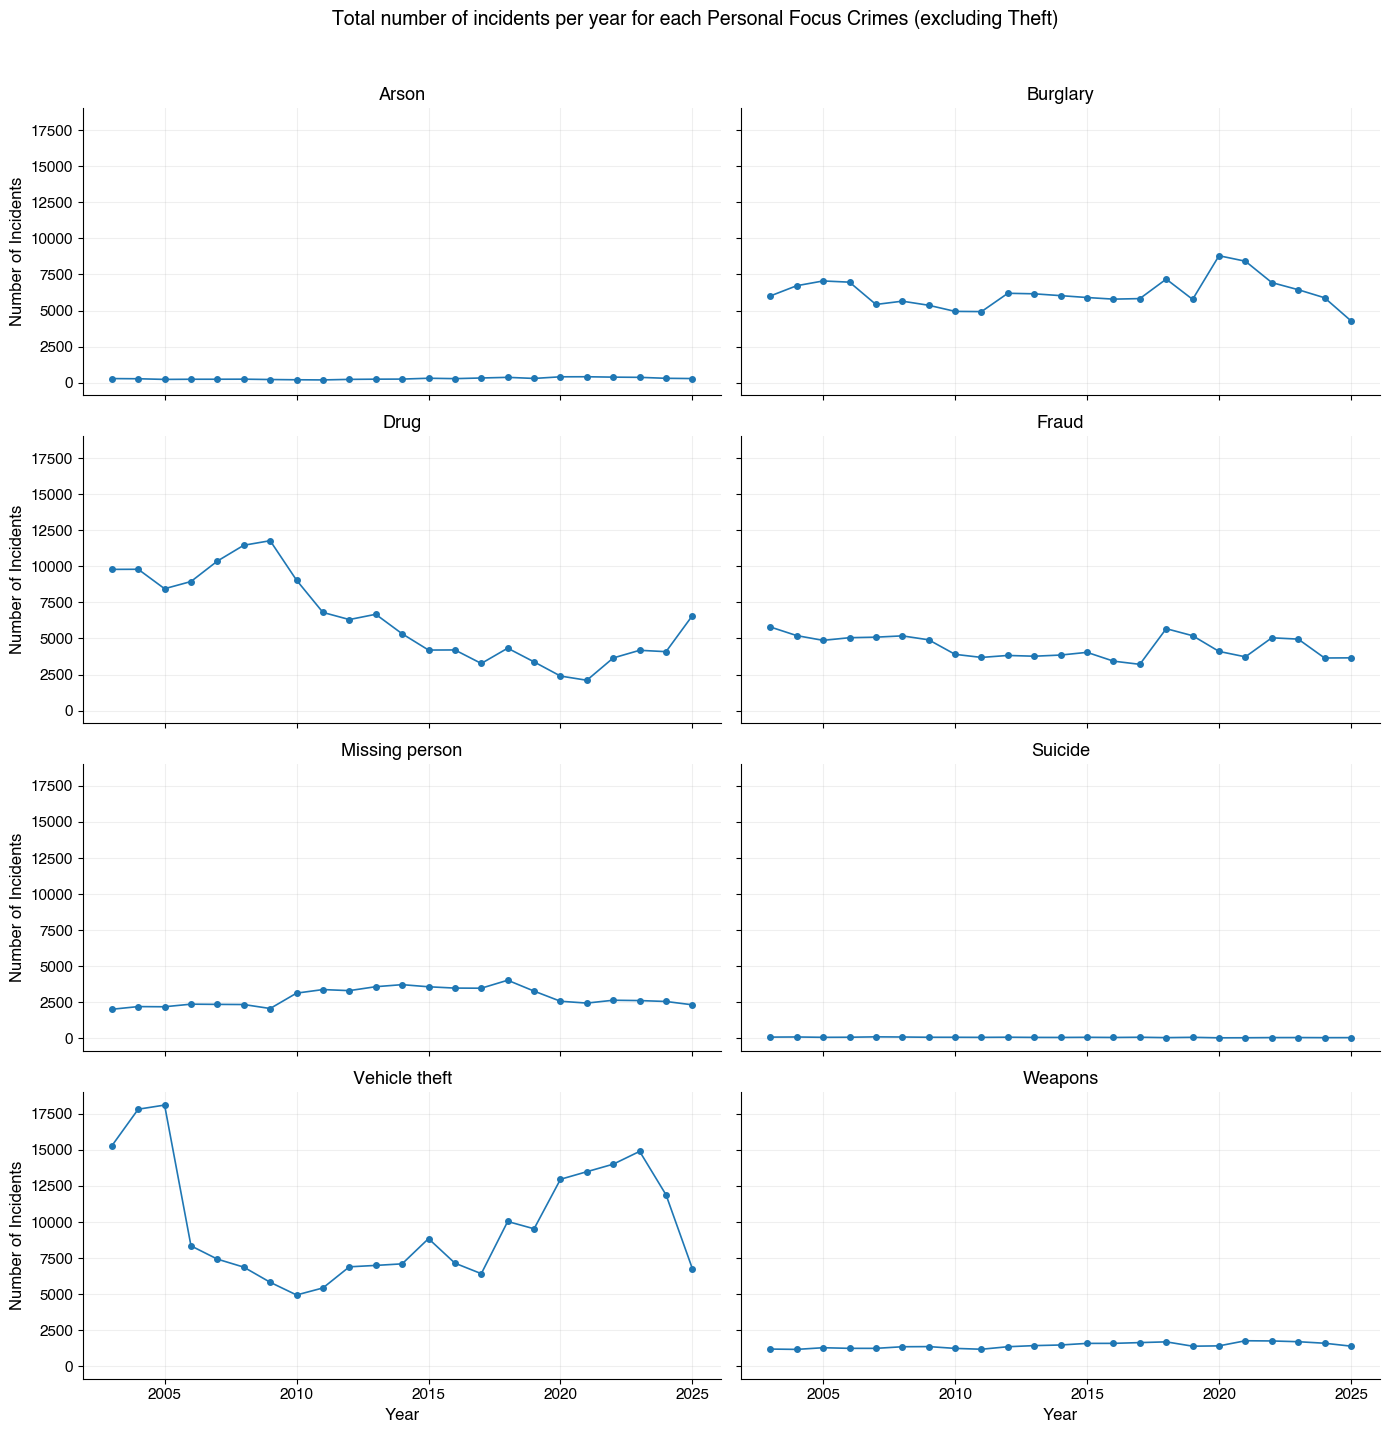

In [61]:
df_plot = (
    df[['Incident Date', 'Incident Category']]
        .assign(Year=lambda x: x['Incident Date'].dt.year)
        .groupby(['Year', 'Incident Category'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
)

# Plotting rest of the focus crimes
df_plot_rest = df_plot.drop(columns=['theft'])

cols = df_plot_rest.columns
years = df_plot_rest.index
labels = [str(c).capitalize() for c in cols]

n = len(labels)
ncols = 2
nrows = math.ceil(n/ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True, sharey=True)
axes = axes.ravel()

# Plot for each type of crime
for ax, col, label in zip(axes, cols, labels):
       ax.plot(years, df_plot_rest[col],marker="o", markersize=4, linewidth=1.2)
       ax.set_title(label)
       ax.grid(True, alpha=0.2)

       ax.spines['top'].set_visible(False)
       ax.spines['right'].set_visible(False)
       
for ax in axes[::ncols]:
       ax.set_ylabel('Number of Incidents')
       
for ax in axes[-ncols:]:
       ax.set_xlabel('Year')

fig.suptitle('Total number of incidents per year for each Personal Focus Crimes (excluding Theft)', fontsize=14, y=1.02)
       
fig.tight_layout()
       
plt.show()

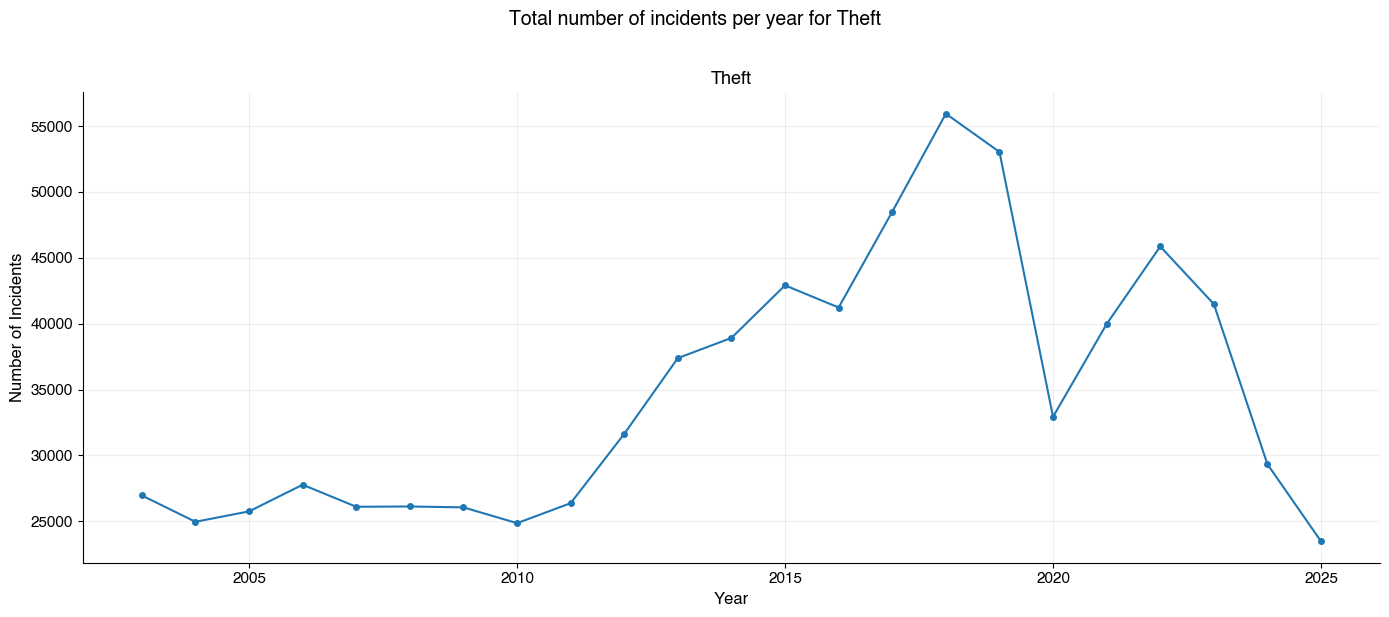

In [62]:
# Plot theft on its own
df_plot_theft = df_plot['theft']

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(years, df_plot_theft, marker="o", markersize=4, linewidth=1.5)

ax.set_title('Theft')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')

ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Total number of incidents per year for Theft', fontsize=14, y=1.02)

fig.tight_layout()
plt.show()


---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [63]:
P_crime = df['Incident Category'].value_counts(normalize=True)

P_crime_given_district = (
    df
    .groupby('Police District')['Incident Category']
    .value_counts(normalize=True) #normalize deilir sjálfkrafa með heildarfjölda
    .unstack(fill_value=0)
)

ratio = P_crime_given_district.div(P_crime, axis=1)


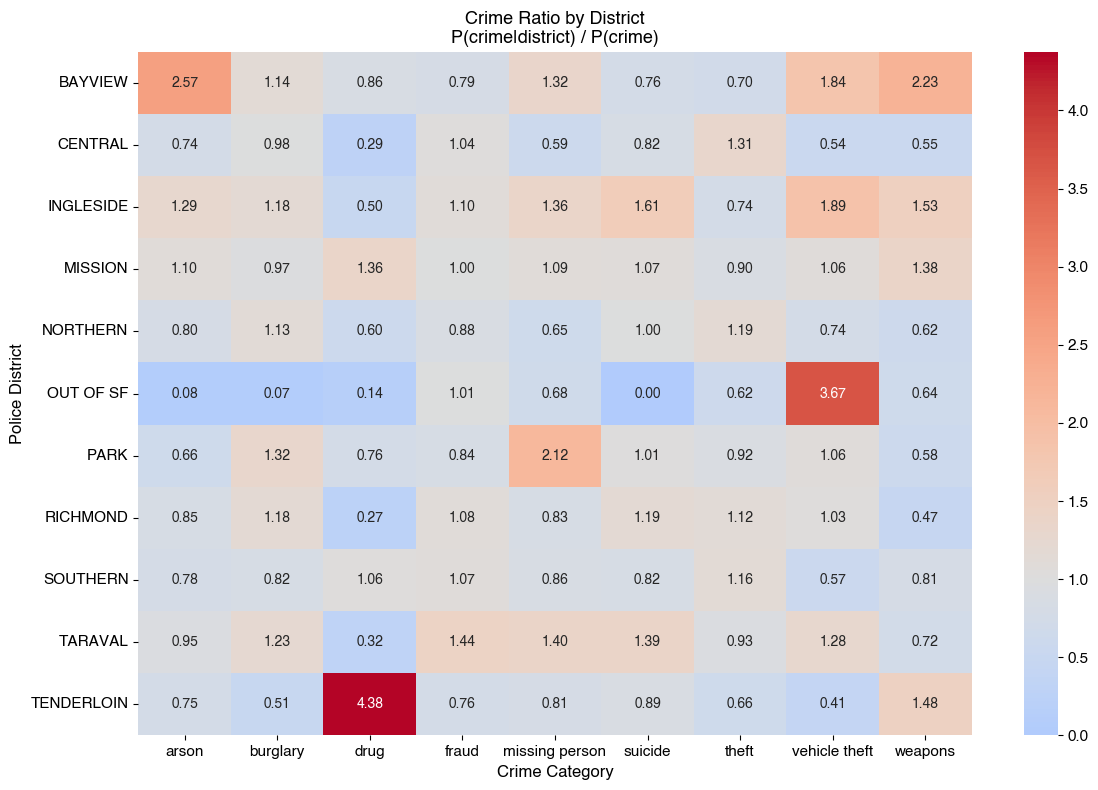

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    ratio,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=1
)

plt.title("Crime Ratio by District\nP(crime|district) / P(crime)")
plt.ylabel("Police District")
plt.xlabel("Crime Category")
plt.tight_layout()
plt.show()

### 

Tenderloin stood out, as it has a very high ratio in drug offences. When looking into it we found that the area has a reputation for crime, homelessness and open-air drug markets. It is the center of the fentannyl crisis in San Fransisco. 
It is interesting that even though the ratio for drug offence is high, other crime ratios do not stand out as much...

---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

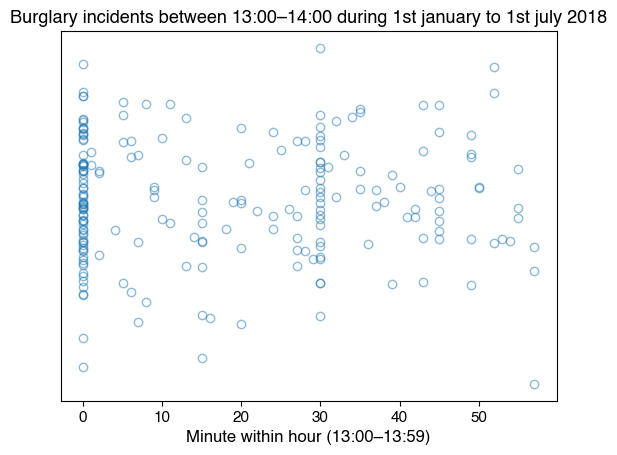

In [65]:
# PART A - Jitter plot
# crime type and a time interval
# on the hour 13-14
import random 
import numpy as np

crime = 'vehicle theft'
start_date = '2018-01-01'
end_date = '2018-07-01'
hour = '13'

mask = (
    (df['Incident Category'] == crime)
    & (df['Incident Date'] >= start_date)
    & (df['Incident Date'] < end_date)
    & (df['Incident Time'].fillna('').str[:2] == hour)
)

df_filtered = df.loc[mask]

x = df_filtered['Incident Time'].str[3:].astype('int')
y = np.random.normal(loc=0, scale=0.05, size=len(x))

    
# Count no of instances
fig, ax = plt.subplots()
ax.plot(x, y, marker ='o', linestyle='none',  markerfacecolor='none', alpha=0.5)
ax.yaxis.set_visible(False)
ax.set_xlabel('Minute within hour (13:00–13:59)')
ax.set_title('Burglary incidents between 13:00–14:00 during 1st january to 1st july 2018')

plt.show()

##
many values at 00, 30, 45. Not always accurate on the minutes... What does this tell you about the precision...

In [66]:
df['Latitude'].min(), df['Latitude'].max(), df['Longitude'].min(), df['Longitude'].max(), 

(37.70784759521, 90.0, -122.51364206429, -120.5)

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_35312/583249386.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Latitude'] = pd.to_numeric(df_filtered['Latitude'], errors='coerce')
/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_35312/583249386.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Longitude'] = pd.to_numeric(df_filtered['Longitude'], errors='coerce')


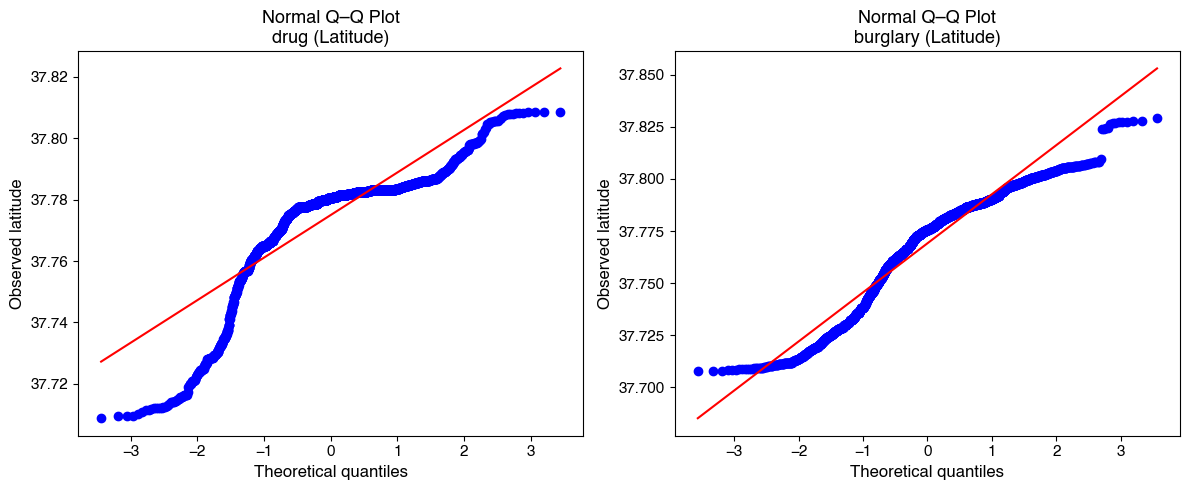

In [67]:
# Histogram
# Two crimes,

crimes = ['drug', 'burglary']
start_date = '2018-01-01'
end_date = '2018-07-01'


mask = (
    (df['Incident Category'].isin(crimes))
    & (df['Incident Date'] >= start_date)
    & (df['Incident Date'] < end_date)
)

df_filtered = df.loc[mask]

# Ensure numeric
df_filtered['Latitude'] = pd.to_numeric(df_filtered['Latitude'], errors='coerce')
df_filtered['Longitude'] = pd.to_numeric(df_filtered['Longitude'], errors='coerce')
# Create a probability plot

from scipy.stats import probplot


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, crime_i in zip(axes, crimes):
    X = df_filtered.loc[
        df_filtered['Incident Category'] == crime_i,
        'Latitude'
    ]
    X = pd.to_numeric(X, errors='coerce').dropna()

    probplot(X, dist="norm", plot=ax)
    ax.set_title(f"Normal Q–Q Plot\n{crime_i} (Latitude)")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Observed latitude")

plt.tight_layout()
plt.show()

# What reference distribution are you comparing against? 
#   Normal bell-shaped distribution 
# What would it mean if the points fell exactly on the straight line? 
#   It would mean that crime locations are spread out in a smooth, bell-shaped way from north to south
# Why might the latitude distributi°on of crimes deviate from normal 
#   Some neighbourhoods might have a higher crime rate than others
# What does the deviation tell you about the geography of crime in SF?
#   It shows that crime is clustered in certain neighborhoods, not spread evenly across the city.


/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_35312/15300250.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df['Incident Time'])


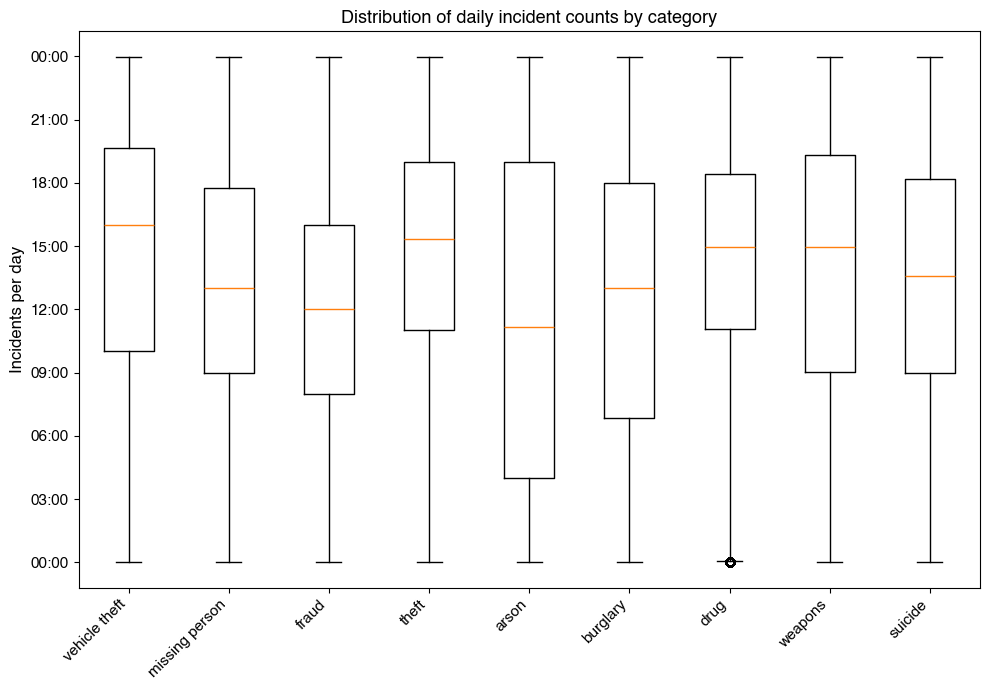

In [68]:
# Calculate the average for each focus-crime, namely what time of day the crime happens. 
# So this time, the distribution we want to plot is the average time-of-day that a crime takes place. 
# For datapoint, the only thing you care about is the time-of-day, so discard everything else.
    # Convert it to hour and minute/second as a percentage of an hour
    
dt = pd.to_datetime(df['Incident Time'])

focus_crimes = df['Incident Category'].unique()

df_time_of_day = pd.DataFrame({
    'time_of_day': dt.dt.hour + (dt.dt.minute * 60 + dt.dt.second)/ 3600.0,
    'datetime': dt,
    'Incident Category': df['Incident Category']
})


data = [
    df_time_of_day.loc[df_time_of_day['Incident Category'] == crime, 'time_of_day']
                  .dropna()
                  .to_numpy()
    for crime in focus_crimes
]

fig, ax = plt.subplots(figsize=(10, 7))
bp = ax.boxplot(data, labels=focus_crimes)

# y-axis ticks every 3 hours
yticks = np.arange(0, 25, 3)
ax.set_yticks(yticks)

# map shifted time back to clock time
ylabels = [f"{int((y) % 24):02d}:00" for y in yticks]
ax.set_yticklabels(ylabels)

ax.set_ylabel("Incidents per day")
ax.set_title("Distribution of daily incident counts by category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# For crimes that peak late at night, does the box plot do a good job of showing the "typical" time?
# What goes wrong when the distribution wraps around midnight (e.g., a crime that peaks between 11pm and 1am)? 
# Can you think of a way to handle this?
#   Its weird that the peak is around 14/15 in all cases, I will try to shift it around for 6 hours and see what happens

# TODO: Do we want to create a violin/... plot instead?


skrýtið plot, gefur skrýtna mynd af þessu, tala eitthvað um það hér

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

In [71]:
# for map
#pip install contextily

In [72]:
# Filter thefts only
theft_df = df[df['Incident Category'] == 'theft']

# Remove extreme outliers (rough SF peninsula bounding box)
theft_df = theft_df[
    (theft_df['Latitude'] > 37.6) &
    (theft_df['Latitude'] < 37.84) &
    (theft_df['Longitude'] > -122.55) &
    (theft_df['Longitude'] < -122.35)
]

# Create spatial bins (approx 100m resolution)
lat_bins = np.linspace(theft_df['Latitude'].min(),
                       theft_df['Latitude'].max(),
                       100)

lon_bins = np.linspace(theft_df['Longitude'].min(),
                       theft_df['Longitude'].max(),
                       100)

# 2D histogram = crime counts per grid cell
H, xedges, yedges = np.histogram2d(
    theft_df['Latitude'],
    theft_df['Longitude'],
    bins=[lat_bins, lon_bins]
)

# Flatten grid counts
crime_counts = H.flatten()

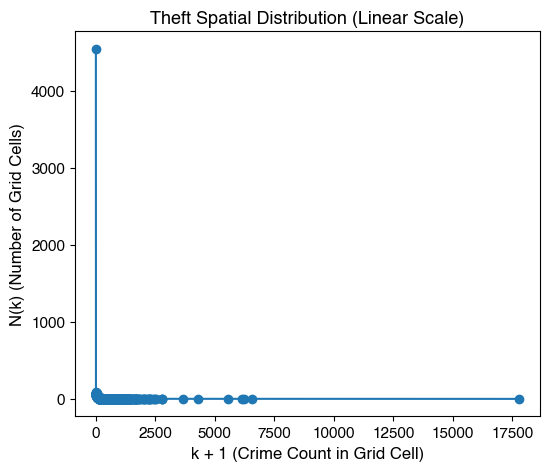

In [73]:
# Keep zeros (do NOT filter them out)
unique, counts = np.unique(crime_counts, return_counts=True)

k_values = unique
N_k = counts

plt.figure(figsize=(6,5))
plt.plot(k_values + 1, N_k, marker='o')
plt.xlabel("k + 1 (Crime Count in Grid Cell)")
plt.ylabel("N(k) (Number of Grid Cells)")
plt.title("Theft Spatial Distribution (Linear Scale)")
plt.show()

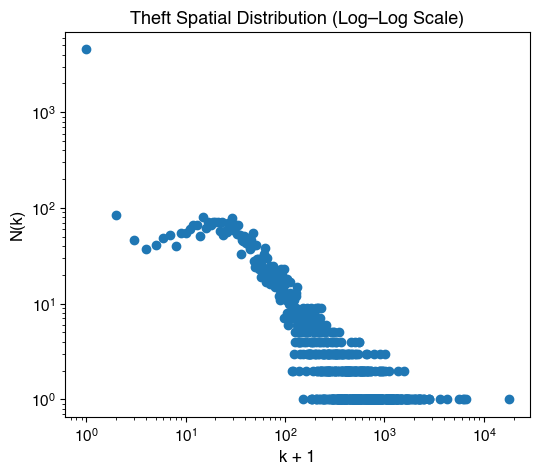

In [74]:
plt.figure(figsize=(6,5))
plt.loglog(k_values + 1, N_k, marker='o', linestyle='')
plt.xlabel("k + 1")
plt.ylabel("N(k)")
plt.title("Theft Spatial Distribution (Log–Log Scale)")
plt.show()

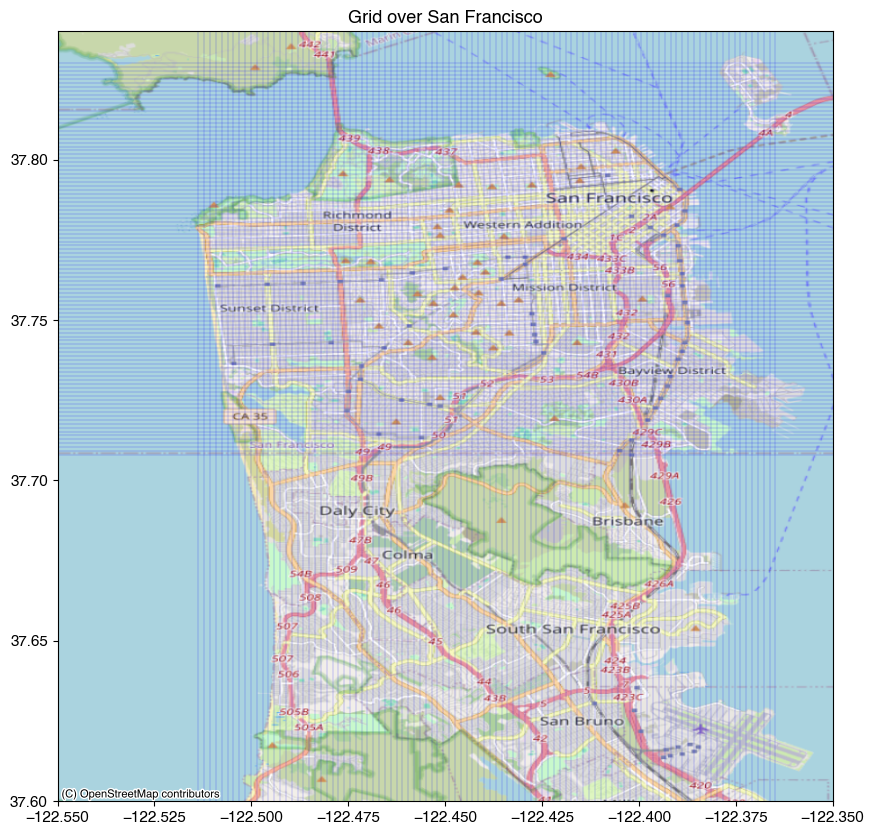

In [75]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the grid lines
for lat in lat_bins:
    ax.axhline(lat, color='blue', linewidth=0.3, alpha=0.5)
for lon in lon_bins:
    ax.axvline(lon, color='blue', linewidth=0.3, alpha=0.5)

# Set extent to SF bounds
ax.set_xlim(-122.55, -122.35)
ax.set_ylim(37.6, 37.84)

# Add basemap (requires contextily: pip install contextily)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Grid over San Francisco")
plt.show()

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

In [88]:
def compute_linear_fit(x,y):
    N = len(x)
    x_mean = x.mean()
    y_mean = y.mean()
    
    den = np.sum(x * y) - N *x_mean*y_mean
    nom = np.sum(x*x) - N * x_mean**2
    
    a = den/nom
    
    b = y_mean - a * x_mean
    
    return a, b

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_35312/1632358171.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df["Incident Time"])


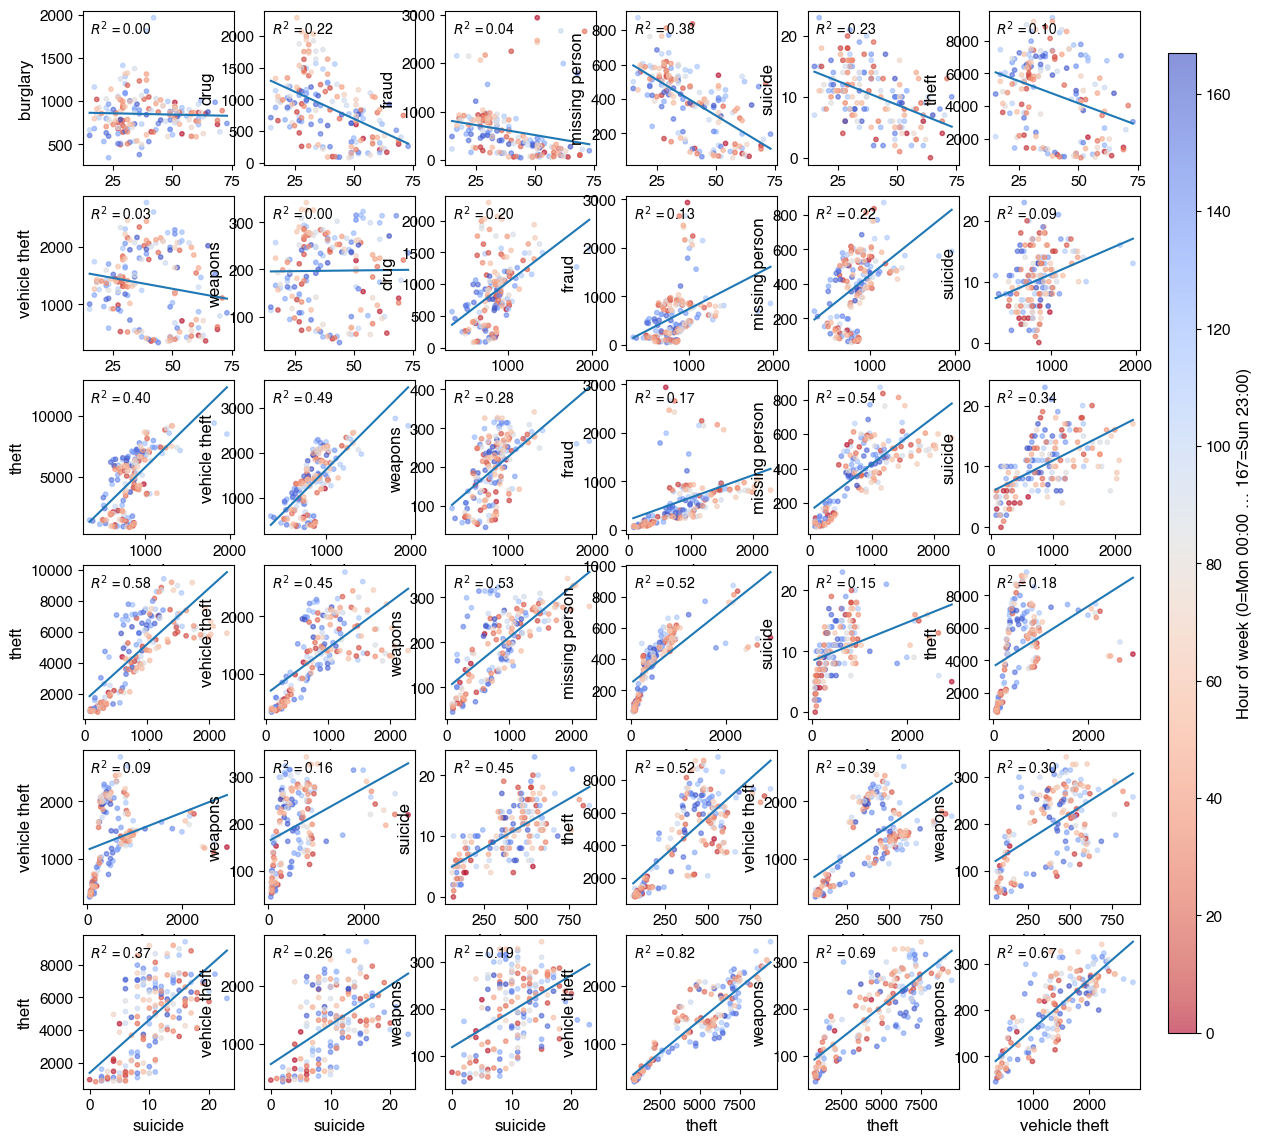

In [104]:
import itertools
from sklearn.metrics import r2_score
from matplotlib.colors import Normalize

# --- Prepare data ---
dt = pd.to_datetime(df["Incident Time"])
df["Incident Hour"] = dt.dt.hour

df_hours = (
    df.groupby(["Incident Day of Week", "Incident Hour", "Incident Category"])
      .size()
      .unstack(fill_value=0)
)

# --- Pick 9 categories (need 9 for 36 plots) ---
cols9 = df_hours.columns[:9]
if len(cols9) < 2:
    raise ValueError(f"Not enough categories to plot. Found {len(cols9)} columns in df_hours.")

X = df_hours[cols9]
pairs = list(itertools.combinations(cols9, 2))

# --- Build hour-of-week color vector (0..167) robustly ---
day_vals = df_hours.index.get_level_values(0)
hour_vals = df_hours.index.get_level_values(1)

# If day is already numeric 0..6, use it
if pd.api.types.is_numeric_dtype(day_vals):
    day_num = pd.Series(day_vals, index=df_hours.index).astype(int)

else:
    # Normalize day strings: "Monday", "mon", "Mon", etc.
    s = pd.Series(day_vals, index=df_hours.index).astype("string").str.strip().str.lower()

    day_map = {
        "monday": 0, "mon": 0,
        "tuesday": 1, "tue": 1, "tues": 1,
        "wednesday": 2, "wed": 2,
        "thursday": 3, "thu": 3, "thur": 3, "thurs": 3,
        "friday": 4, "fri": 4,
        "saturday": 5, "sat": 5,
        "sunday": 6, "sun": 6,
    }
    day_num = s.map(day_map)

# Sanity check: if mapping failed, stop with a helpful error
if day_num.isna().any():
    bad = day_vals[pd.isna(day_num)].unique()[:10]
    raise ValueError(f"Unrecognized day-of-week values (examples): {bad}. Fix the mapping or normalize the column.")

hour_of_week = day_num.to_numpy() * 24 + pd.Series(hour_vals, index=df_hours.index).to_numpy()
norm = Normalize(vmin=0, vmax=167)

# --- Plot 6x6 layout ---
fig, axes = plt.subplots(6, 6, figsize=(14, 14))
axes = axes.ravel()

sc = None
for ax, (x_col, y_col) in zip(axes, pairs):
    x = X[x_col]
    y = X[y_col]

    # drop NaNs (usually none here, but safe)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    c = hour_of_week[mask.to_numpy()]

    a, b = compute_linear_fit(x, y)
    y_pred = a * x + b
    r2 = r2_score(y, y_pred)

    sc = ax.scatter(
        x, y,
        c=c,
        cmap="coolwarm_r",   # red -> blue
        norm=norm,
        alpha=0.6,
        s=10
    )

    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a * x_line + b)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.2f}",
        transform=ax.transAxes,
        va="top"
    )
# Hide unused axes
for ax in axes[len(pairs):]:
    ax.set_visible(False)

# Make room on right
fig.subplots_adjust(right=0.88)

# Add single colorbar
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("Hour of week (0=Mon 00:00 … 167=Sun 23:00)")

plt.show()